In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)


In [8]:
df = pd.read_excel("cgpaPRED.xls")
df.columns

Index(['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4', 'SEM 5'], dtype='str')

In [9]:
df.head()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


In [10]:
x = df.drop(columns=['SEM 5'])
y = df['SEM 5']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

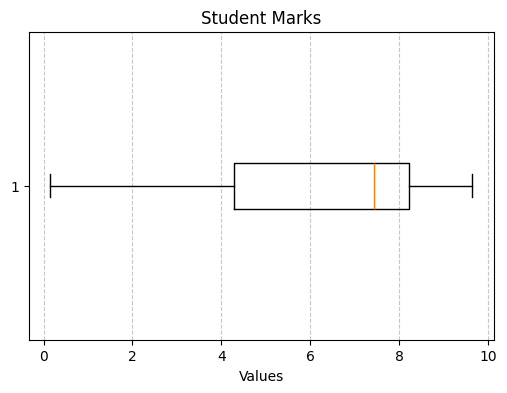

In [11]:
plt.figure(figsize=(6, 4))
plt.boxplot(y, vert=False)
plt.title("Student Marks")
plt.xlabel("Values")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


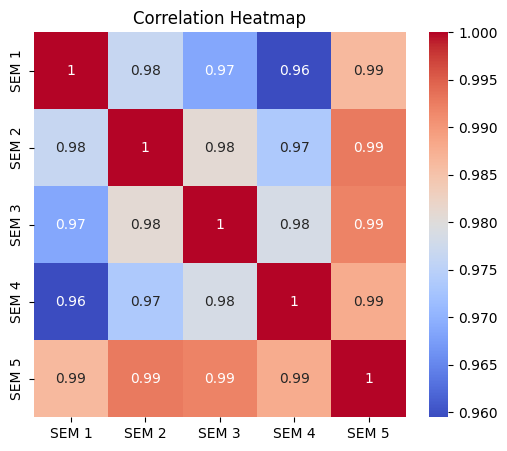

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
mlr = LinearRegression()
mlr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = mlr.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  = {mse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")


----- Multiple Linear Regression -----
MSE  = 0.0000
MAE  = 0.0023
RMSE = 0.0027
R2   = 1.0000


In [16]:
print("\nEquation:")
print(f"SEM 5 = {mlr.intercept_:.4f}", end="")

for coef, col in zip(mlr.coef_, x.columns):
    print(f" + ({coef:.4f} * {col})", end="")
print()


Equation:
SEM 5 = 0.0036 + (0.2499 * SEM 1) + (0.2502 * SEM 2) + (0.2499 * SEM 3) + (0.2497 * SEM 4)


In [17]:
ip = df[['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']].mean(axis=1).values.reshape(-1, 1)


In [18]:
s_x_train, s_x_test, s_y_train, s_y_test = train_test_split(
    ip, y, test_size=0.2, random_state=42
)

In [19]:
slr = LinearRegression()
slr.fit(s_x_train, s_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
s_y_pred = slr.predict(s_x_test)


In [ ]:
s_mse = mean_squared_error(s_y_test, s_y_pred)
s_mae = mean_absolute_error(s_y_test, s_y_pred)
s_rmse = root_mean_squared_error(s_y_test, s_y_pred)
s_r2 = r2_score(s_y_test, s_y_pred)

print(f"MSE  = {s_mse:.4f}")
print(f"MAE  = {s_mae:.4f}")
print(f"RMSE = {s_rmse:.4f}")
print(f"R2   = {s_r2:.4f}")


----- Simple Linear Regression -----
MSE  = 0.0000
MAE  = 0.0024
RMSE = 0.0027
R2   = 1.0000


In [ ]:
print("\nEquation:")
print(f"SEM 5 = {slr.intercept_:.4f} + ({slr.coef_[0]:.4f} x Average of SEM1-SEM4)")


Equation:
SEM 5 = 0.0035 + (0.9997 × Average of SEM1-SEM4)


In [26]:
while True:
    user_choice = input("Do you want to predict SEM 5? (y/n): ").lower()

    if user_choice == "n":
        print("Goodbye")
        break
    elif user_choice == "y":
        s1 = float(input("Enter SEM 1: "))
        s2 = float(input("Enter SEM 2: "))
        s3 = float(input("Enter SEM 3: "))
        s4 = float(input("Enter SEM 4: "))

        pred = mlr.predict([[s1, s2, s3, s4]])
        print(f"Predicted SEM 5: {pred[0]:.2f}\n")
    else:

        print("Please enter 'y' or 'n'.\n")

Predicted SEM 5: 8.65



c:\Users\prabh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Please enter 'y' or 'n'.

Please enter 'y' or 'n'.

Please enter 'y' or 'n'.

Please enter 'y' or 'n'.

Goodbye


In [ ]:
test=[]
for i in x.columns:
    test.append(float(input(f"{i} : ")))
print("model predicted : ",round(model.predict([test]),4))

In [27]:
print("model predicted : ", round(mlr.predict([[float(input(f"{i} : ")) for i in x.columns]])[0], 4))

model predicted :  8.501


c:\Users\prabh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
